# Choosing the best optimizer for you 
In this how-to, we will show you how to use `dygdug` with `prysm.x.optym`'s optimizers to search for the best optimizer for your problem. This tutorial picks up where we left off in the Optimizing Coronagraphs how-to, so we will start by setting up the problem as we did before, first with the `Coronagraph` object 

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from prysm.propagation import prepare_executor 
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT
from prysm.mathops import set_backend_to_cupy, np
from tqdm import tqdm

from dygdug.masks import Pupil, FPM
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph


# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 512
Nfoc = 128
wvl = 1 
fno = 13.66
efl = fno * circumscribed_diameter 
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4 # the "oversampling"
seg_diam = VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT * 1800

# Define VARIABLE entrance pupil
pupil = VariablePupil.hexagonal_segmented(
    Dpup=circumscribed_diameter, 
    Npup=Npup,
    rings=3,                 
    segment_diameter=seg_diam, 
    segment_separation=5, 
    exclude=(0,),
    mode="phase" # special argument for VariablePupil
)

# ensure we are using the GPU backend
set_backend_to_cupy()

# update the VariablePupil data to be a cupy array
pupil.data = np.asarray(pupil.data)

# Define a prysm executor the controls the propagation
executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

# Define focal plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Define the lyot stop
lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.2 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

/home/jarenashcraft/anaconda3/envs/prysm_test/lib/python3.10/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Next we set up the optimization problem

In [2]:
from dygdug.coropt import CoronagraphOptimizer
from dygdug.cost_functions import FieldMeanSquaredError
from dygdug.masks import annular_mask, ImgSamplingSpec, knife_edge_mask

# Define Image Plane Sampling Specification and Dark Hole
iss = ImgSamplingSpec(Nfoc, px_per_lamD, lamD=lamD)
dark_hole = annular_mask(iss, iwa=3, owa=12, theta_min=-90, theta_max=90)
dark_hole *= knife_edge_mask(iss, iwa=3)

# Define cost function
target_contrast = 1e-10
target_field = np.sqrt(target_contrast)
cost_function = FieldMeanSquaredError(target=target_field)

# Define the starting parameter vector
x0 = np.zeros_like(pupil.data[pupil.mask], dtype="float64")

# Define the CoronagraphOptimizer
coroopt = CoronagraphOptimizer(
    dark_hole=dark_hole,
    coro=coro,
    wvl=[wvl], # just perform monochromatic for now
    cost=cost_function
)


Next, we import the `optym` optimizers. This how-to will be organized by each optimizer currently available in `prysm`. 

# Gradient Descent
Gradient descent might be the conceptually simplest optimizer available in `x.optym`. You start by determining the gradient direction, and then step in the opposite direction by a user-defined "learning rate" called `alpha`. Here, as with other optimizers, we will perform a log-scan of learning rates for the first couple of iterations to determine which learning rate is best for our problem.

  2%|▏         | 16/1000 [00:00<00:06, 155.80it/s]

100%|██████████| 1000/1000 [00:02<00:00, 358.70it/s]


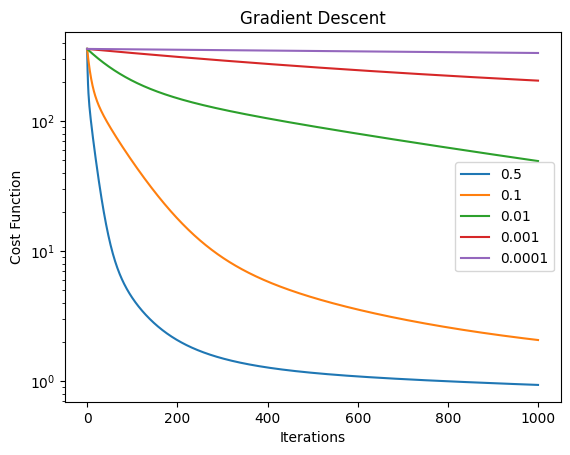

In [3]:
from prysm.x.optym import GradientDescent
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = GradientDescent(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("Gradient Descent")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

It looks like the steepest learning rate best minimized our cost function, let's plot it and see what the solution looks like

100%|██████████| 1000/1000 [00:02<00:00, 357.82it/s]


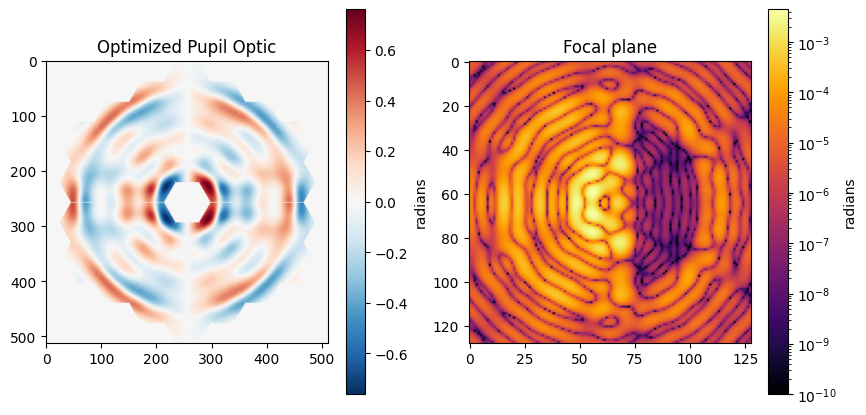

In [4]:
# Re-set the solution
coro.pupil.update(x0)

opt = GradientDescent(fg=coroopt.fg, x0=x0, alpha=0.5)
cost = []
N_ITER = 1000

# Perform inner solution finding
for j in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)


xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

# AdaGrad
AdaGrad, or Adaptive Gradient is an optimization algorithm that adapts the learning rate for each parameter based on prior gradients. Otherwise, it (in principle), operates similarly to Gradient Descent

100%|██████████| 1000/1000 [00:02<00:00, 355.61it/s]


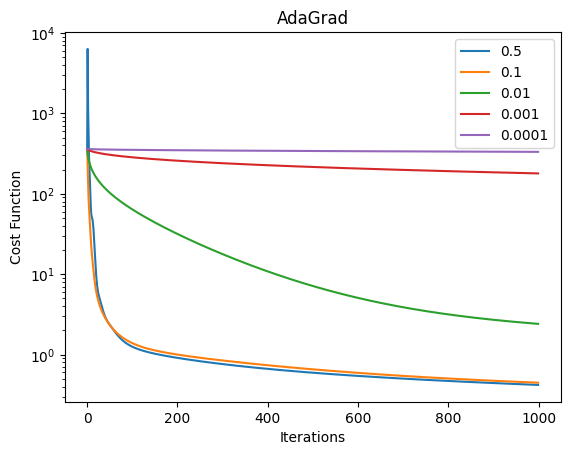

In [5]:
from prysm.x.optym import AdaGrad
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = AdaGrad(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("AdaGrad")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

Plotting the lowest-cost solution reveals that while the focal plane looks approximately similar to the solution found by Gradient Descent, the pupil plane relies on a much stronger phase apodization. This is undesireable for many reasons, including manufacturability, core throughtput, and sensitivity.

100%|██████████| 1000/1000 [00:02<00:00, 354.86it/s]


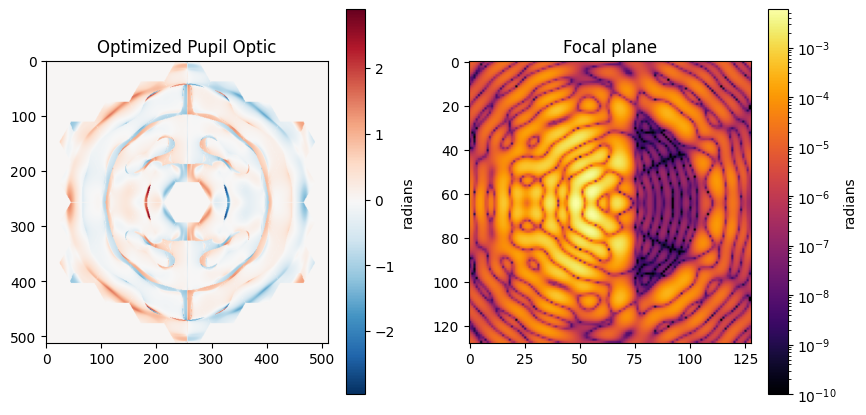

In [6]:
# Re-set the solution
coro.pupil.update(x0)

opt = AdaGrad(fg=coroopt.fg, x0=x0, alpha=0.5)
cost = []
N_ITER = 1000

# Perform inner solution finding
for j in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)


xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

Let's examine one of the other solutions to see if we do better. Examining the next lowest cost shows that we reduce our phase apodization by a nearly a factor of 2, but there are still some very sharp features in the phase apodization that might be difficult to manufacture.

100%|██████████| 1000/1000 [00:02<00:00, 355.23it/s]


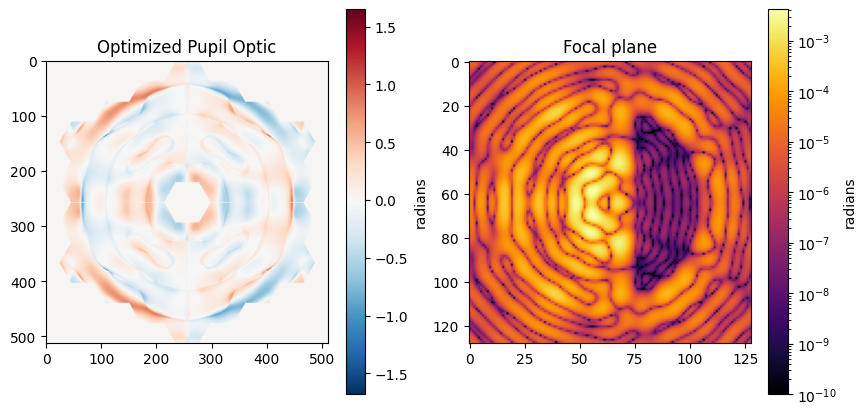

In [19]:
# Re-set the solution
coro.pupil.update(x0)

opt = AdaGrad(fg=coroopt.fg, x0=x0, alpha=0.1)
cost = []
N_ITER = 1000

# Perform inner solution finding
for j in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)


xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

# RMSProp

RMSProp is another adaptive optimization algorithm, like AdaGrad. Where it differs is that the update of the learning rate `alpha` is a little slower, meaning that the optimizer won't (necesarilly) "bottom out" as quickly. Let's see how true that is by performing a log-scan of the starting learning rates for this optimizers. The cost function landscape is already very different.

100%|██████████| 1000/1000 [00:02<00:00, 353.23it/s]


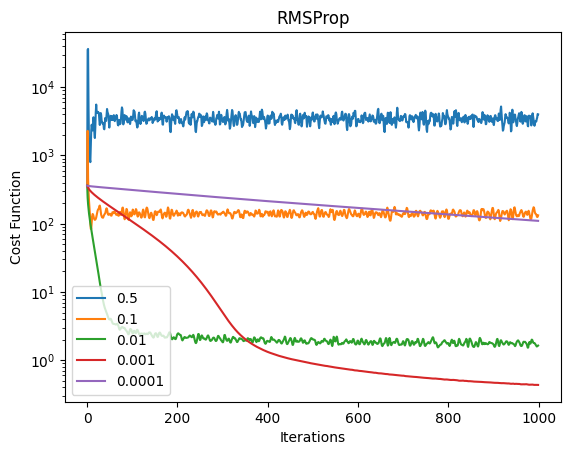

In [7]:
from prysm.x.optym import RMSProp
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = RMSProp(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("RMSProp")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

This time, the highe learning rates "stall out" at a high cost, whereas `alpha=1e-3` has a smooth decrease. While the focal plane looks nearly identical to the prior solutions, the phase apodization is lesser, and there are fewer sharp phase transitions in the pupil plane.

100%|██████████| 1000/1000 [00:02<00:00, 353.28it/s]


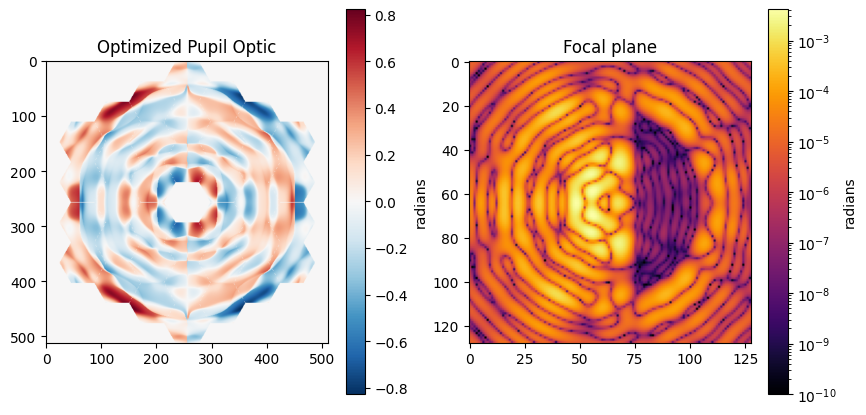

In [23]:
# Re-set the solution
coro.pupil.update(x0)

opt = RMSProp(fg=coroopt.fg, x0=x0, alpha=1e-3)
cost = []
N_ITER = 1000

# Perform inner solution finding
for j in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)


xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

# Adam

Adam, or Adaptive Moment Estimation, comebines the concepts of Momentum and RMSProp for faster and more robust optimization. Momentum accelerates gradient descent by the moving average of prior gradients for faster and smoother convergence, while RMSProp adapts the learning rate to prevent it from decreasing too quickly.

100%|██████████| 1000/1000 [00:02<00:00, 350.15it/s]


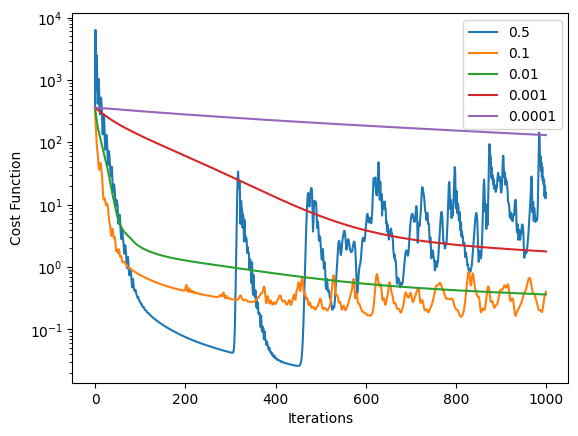

In [8]:
from prysm.x.optym import Adam 
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = Adam(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

Here we will instead plot the "smoothest" solution. While technically the large learning rate hit the lowest cost first, the solution space is not stable, which tends to produce sub-optimal designs. The design corresponding to `alpha=1e-2` shows the steepest and smoothest convergence of the learning rates, and overall has very low phase apodization with a few areas with sharp transitions in phase.

100%|██████████| 1000/1000 [00:02<00:00, 348.19it/s]


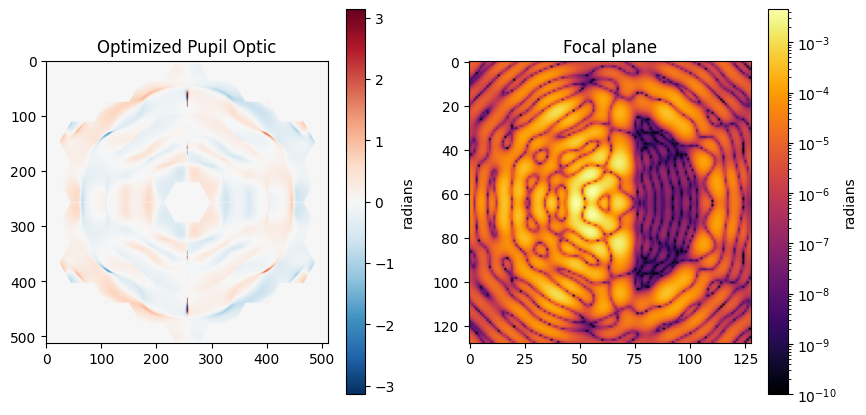

In [30]:
# Re-set the solution
coro.pupil.update(x0)

opt = Adam(fg=coroopt.fg, x0=x0, alpha=1e-2)
cost = []
N_ITER = 1000

# Perform inner solution finding
for j in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)


xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

# RAdam
RAdam is the Rectified Adam optimizer. Traditionally, folks will use the Adam optimizer with a low learning rate in the early stages of training as a "warmup" period, which can minimize convergence on local minima. RAdam attempts to "rectify" this behavior by estimating the variance of the squared gradient moving average, and scaling subsequent updates to rectify the variance. The intention is to remove the need for this learning rate warmup period. The cost function landscapes illustrate this behavior, with overall more stable convergence of the higher learning rates.

100%|██████████| 1000/1000 [00:02<00:00, 347.86it/s]


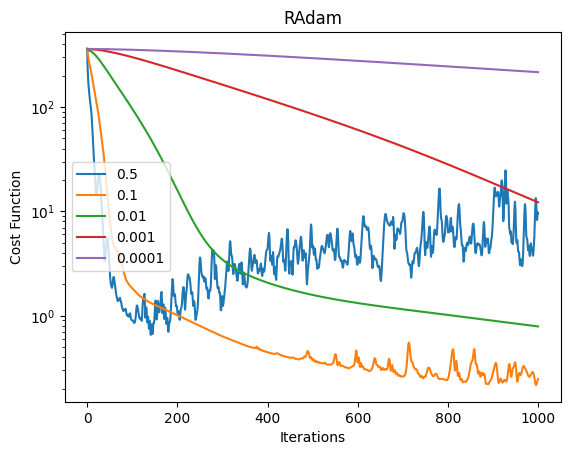

In [31]:
from prysm.x.optym import RAdam
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = RAdam(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("RAdam")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

The `alpha=1e-2` case finds a nearly identical solution to Adam, so let's take a look at `alpha=1e-1`. The overall phase apodization is perhaps slightly greater, but the sharp $\pi$ transition regions are gone.

100%|██████████| 1000/1000 [00:02<00:00, 347.94it/s]


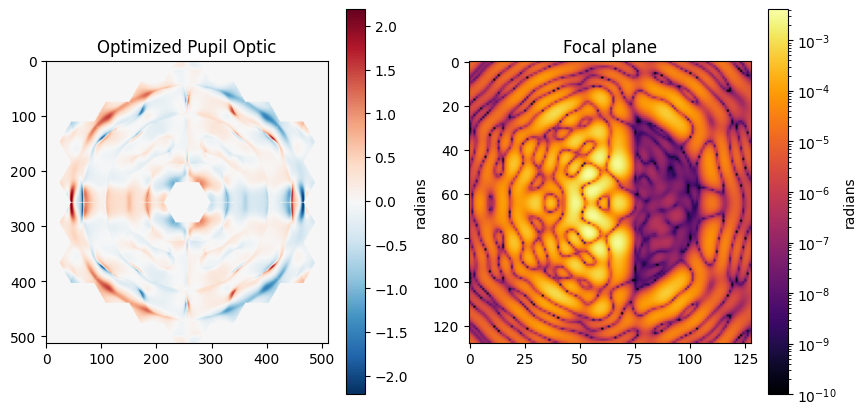

In [34]:
# Re-set the solution
coro.pupil.update(x0)

opt = Adam(fg=coroopt.fg, x0=x0, alpha=1e-1)
cost = []
N_ITER = 1000

# Perform inner solution finding
for j in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)


xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

# AdaMomentum
AdaMomentum is an algorithm that operates very similarly to Adam, but aims to minimize the variance of the correction.

100%|██████████| 1000/1000 [00:02<00:00, 349.17it/s]


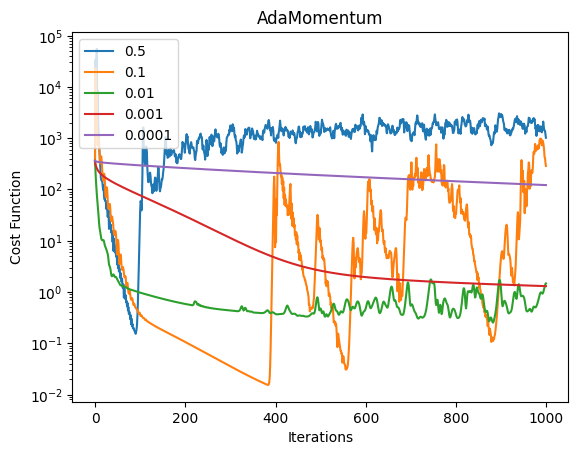

In [10]:
from prysm.x.optym import AdaMomentum
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = AdaMomentum(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("AdaMomentum")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

100%|██████████| 390/390 [00:01<00:00, 347.64it/s]


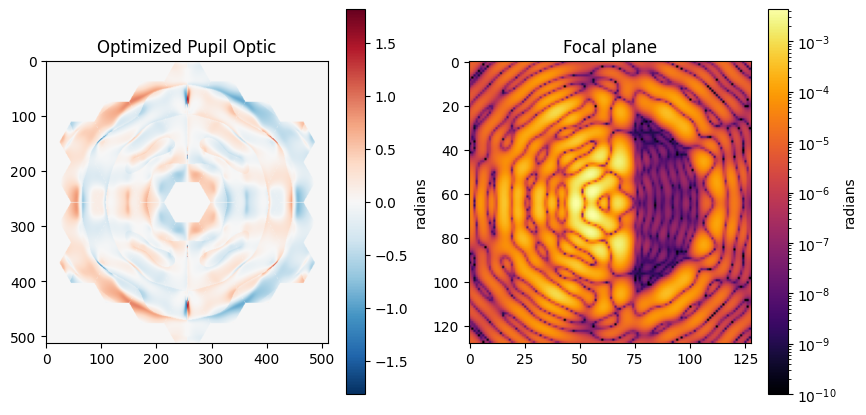

In [41]:
# Re-set the solution
coro.pupil.update(x0)

opt = AdaMomentum(fg=coroopt.fg, x0=x0, alpha=1e-2)
cost = []
N_ITER = 390

# Perform inner solution finding
for j in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)


xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

# Yogi
Yogi is yet another modification of Adam that replaces the update of the exponentially moving average with an additive update. This means that the optimizer tends to not "forget" past gradients too quickly, meaning that it won't be as likely to get stuck in local minima.

100%|██████████| 1000/1000 [00:02<00:00, 349.05it/s]


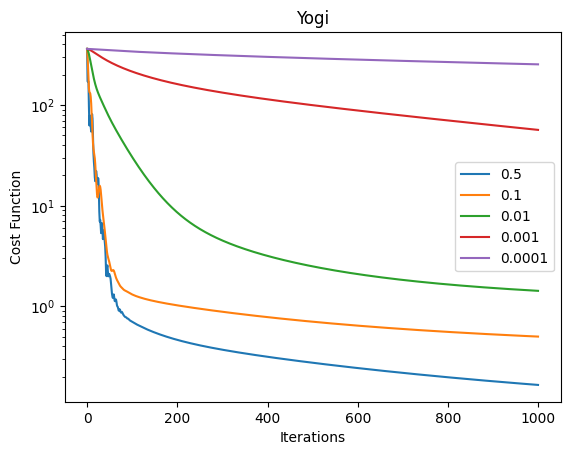

In [11]:
from prysm.x.optym import Yogi
alphas = [0.5, 1e-1, 1e-2, 1e-3, 1e-4]
N_ITER = 1000
plt.figure()

for alpha in alphas:

    # Re-set the solution
    coro.pupil.update(x0)

    opt = Yogi(fg=coroopt.fg, x0=x0, alpha=alpha)
    cost = []

    for i in tqdm(range(N_ITER)):
        opt.step()
        cost.append(coroopt.J)

    xf = opt.x.copy()
    pupil.update(xf)
    field = coro.forward(wvl=wvl, include_fpm=True)
    ref_field = coro.forward(wvl=wvl, include_fpm=False)

    plt.plot(cost, label=alpha)
plt.title("Yogi")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")
plt.show()

100%|██████████| 1000/1000 [00:02<00:00, 347.42it/s]


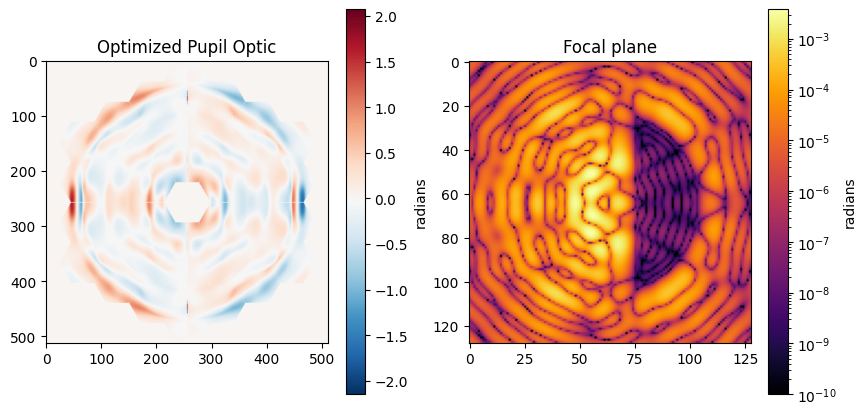

In [39]:
# Re-set the solution
coro.pupil.update(x0)

opt = Yogi(fg=coroopt.fg, x0=x0, alpha=0.5)
cost = []
N_ITER = 1000

# Perform inner solution finding
for j in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)


xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

# L-BFGS with Progressive Refinement
BFGS (and the limited-memory variant, L-BFGS) is a phenomenal optimizer that tends to find very good solutions. Unfortunately, it comes at the cost of higher computational complexity, so we cannot iterate as fast. Let's try add progressive refinement to solve for a "best" PAPLC. This involves attempting to mitigate the total amount of phase apodization used.

100%|██████████| 2000/2000 [00:13<00:00, 147.82it/s]


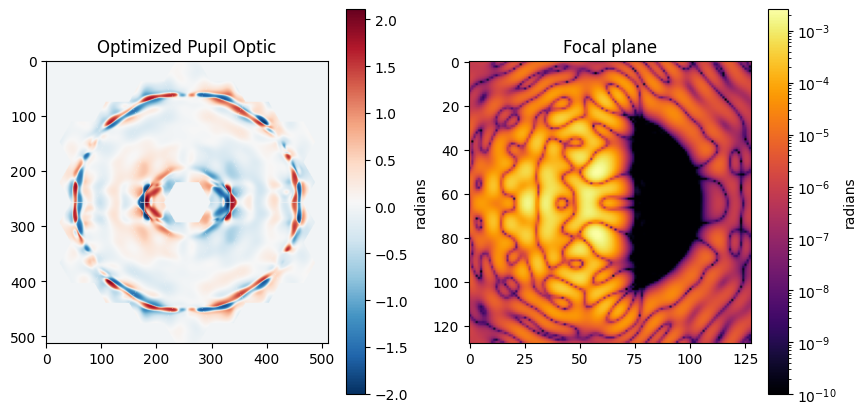

In [48]:
from prysm.x.optym import PrysmLBFGSB
from matplotlib.colors import LogNorm

N_OUTER = 10
N_INNER = 2000

# Re-set the solution
coro.pupil.update(x0)

opt = PrysmLBFGSB(fg=coroopt.fg, x0=x0, memory=10)
cost = []

for i in range(N_OUTER):

    # Perform inner solution finding
    for j in tqdm(range(N_INNER)):
        opt.step()
        cost.append(coroopt.J)

    # provide a "kick" to the solution
    if i < (N_OUTER - 1):
        opt.x *= 0.7

xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(np.angle(pupil.data).get(), cmap="RdBu_r")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity.get(), cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar(label="radians")
plt.show()

Plotting the maximum phase apodization can be a proxy for how manufacturable this device is. Asserting $2\pi$ phase control with something like metasurfaces can be very challenging, so it's critical to control this in design. We find that that the peak-to-valley (PTV) phase apodization is a little over half a wave, making this much more manufacturable than full-wave or greater design.

In [45]:
phase_apodization = np.max(np.abs(np.angle(pupil.data))) / np.pi
print(f"PTV Phase Apodization = {2*phase_apodization:.2f}pi")

PTV Phase Apodization = 1.16pi


We can visualize the "kicks" from the progressive refinement step by plotting the cost function. We observe that the cost function always returns to nearly the same (if not lower) minimum.

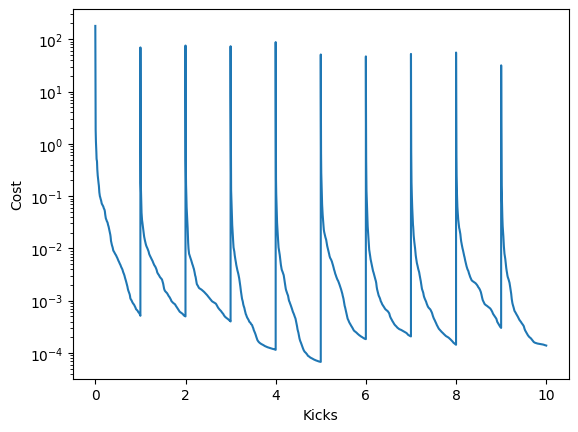

In [49]:
kicks = np.arange(N_INNER * N_OUTER).astype(np.float64)
kicks /= np.float64(N_INNER)

plt.figure()
plt.plot(kicks.get(), cost)
plt.yscale("log")
plt.ylabel("Cost")
plt.xlabel("Kicks")
plt.show()